In [1]:
import seaborn as sns
%matplotlib inline

In [2]:
tips = sns.load_dataset('tips')

In [3]:

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
distplot
The distplot shows the distribution of a univariate set of observations.

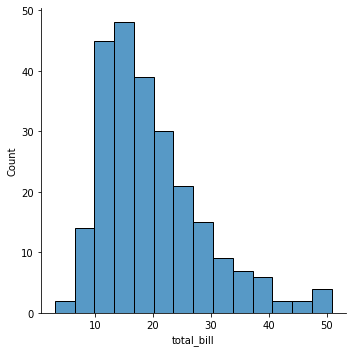

In [5]:
sns.displot(tips['total_bill'])
# Safe to ignore warnings

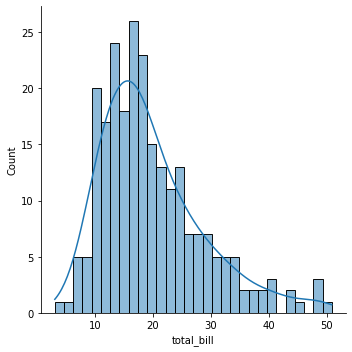

In [11]:
sns.displot(tips['total_bill'],kde=True,bins=30)
#In Seaborn, KDE (Kernel Density Estimation) is used to visualize the probability density of a continuous variable. It is a smooth curve that represents the data distribution, which is an estimate of the underlying distribution.
#The bins parameter is used to control how many bars or segments you want to divide the data into when plotting histograms. If you set bins=30, it will break the data into 30 bins.

In [ ]:
jointplot
jointplot() allows you to basically match up two distplots for bivariate data. With your choice of 
what kind parameter to compare with:
    
A jointplot in Seaborn is a great way to visualize the relationship between two continuous variables. It shows a scatter plot along with marginal histograms (or KDEs) on the top and right sides of the plot,

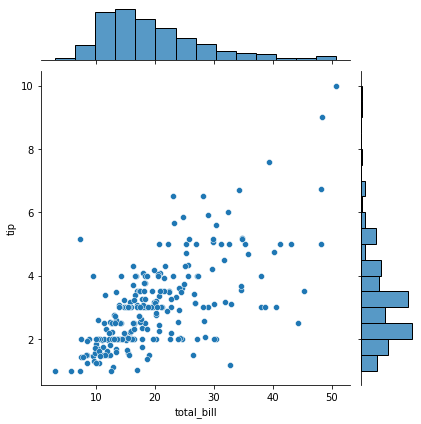

In [11]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')

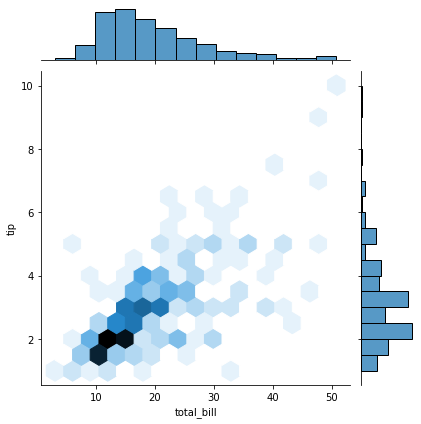

In [5]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')
#In a hexbin plot, the data points are binned into hexagonal cells, and each hexagon is colored according to the number of points that fall into that bin.

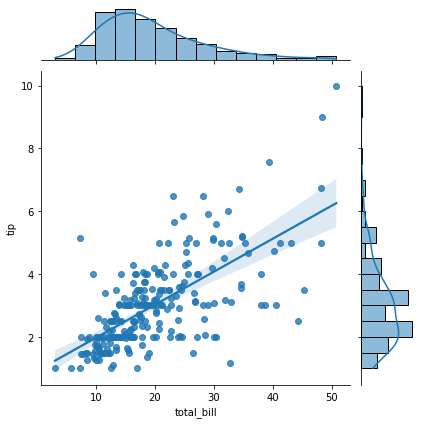

In [13]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')
#A jointplot with kind='reg' creates a regression plot. This plot not only shows the relationship 
#between two continuous variables (just like a scatter plot) but also fits a regression line through the data, making it easy to visually assess the linear relationship.

In [ ]:

pairplot
pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and 
supports a color hue argument (for categorical columns).

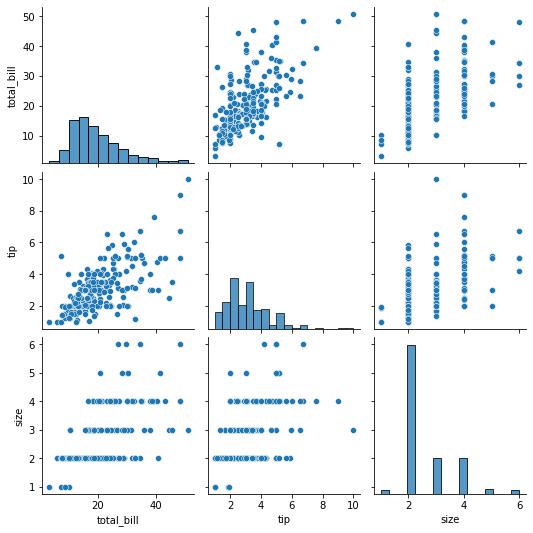

In [14]:
sns.pairplot(tips)

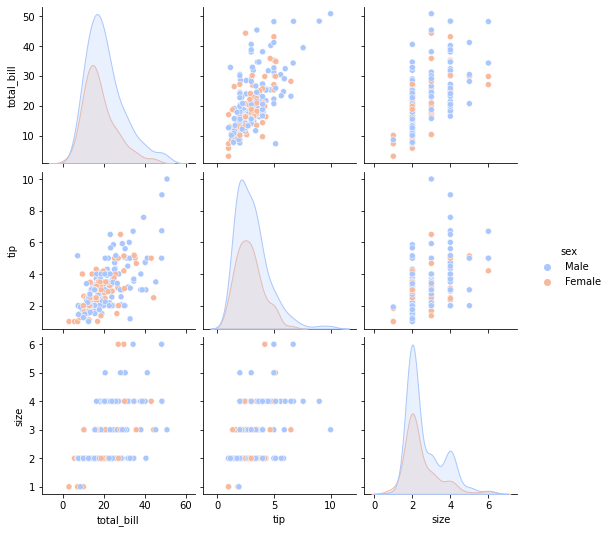

In [3]:
sns.pairplot(tips,hue='sex',palette='coolwarm')

In [ ]:
rugplot
rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:
    kde for Kernal Density estimation or more probability

<AxesSubplot:xlabel='total_bill'>

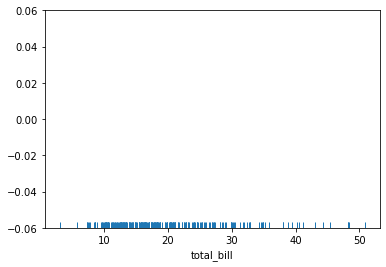

In [4]:
sns.rugplot(tips['total_bill'])

(0.0, 1.0)

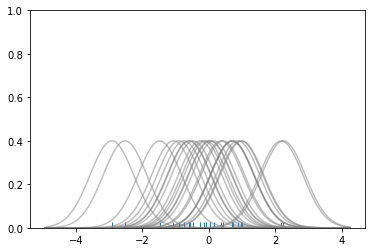

In [8]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sns.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)

Text(0.5, 0.98, 'Sum of the Basis Functions')

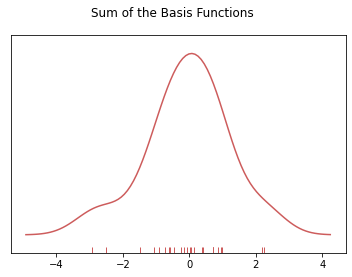

In [9]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")

<AxesSubplot:xlabel='total_bill', ylabel='Density'>

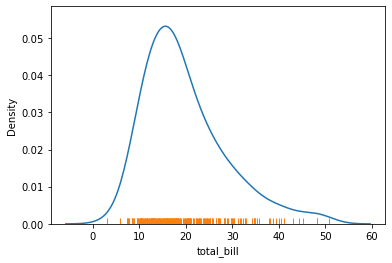

In [11]:
sns.kdeplot(tips['total_bill'])
sns.rugplot(tips['total_bill'])

<AxesSubplot:xlabel='tip', ylabel='Density'>

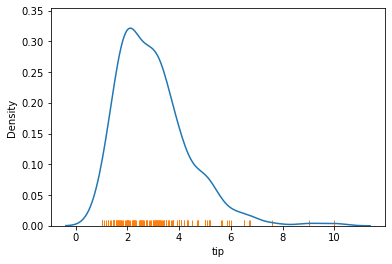

In [12]:
sns.kdeplot(tips['tip'])
sns.rugplot(tips['tip'])